# Settings

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import timm
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import pandas as pd
import librosa.display
from sklearn.model_selection import StratifiedShuffleSplit
from torchvision.transforms import v2 as transforms_v2
import random
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import IPython.display as ipd
from matplotlib import cm

In [2]:
class CFG:
    batch_size = 32

    # Đường dẫn
    train_dir = '/kaggle/input/birdclef-2025/train_audio/'
    train_soundscapes_dir = '/kaggle/input/birdclef-2025/train_soundscapes/'
    model_dir = '/kaggle/working/ModelTuanTran/'

    # Mel Spectrogram
    sample_rate = 32000
    segment_length = 5
    top_db = 80
    n_mels = 256  
    fmin = 20
    fmax = 16000
    n_fft = 2048
    hop_length = 512
    power = 2.0
    norm = 'slaney'
    pad_mode = 'reflect'
    target_shape = (256, 256)
    model_presets = ['efficientnet_b0']
    in_channels = 3

    
    num_epochs = 20
    early_stopping_patience = 5
    learning_rate = 1e-3
    mixup_alpha = 0.4

In [3]:
cfg = CFG()
os.makedirs(cfg.model_dir, exist_ok=True)

In [4]:
paths = cfg.model_dir
if os.path.exists(paths):
        print(f"{paths} ✅ tồn tại.")
else:
        print(f"{paths} ❌ không tồn tại.")

/kaggle/working/ModelTuanTran/ ✅ tồn tại.


---

# Exploratory Data Analyst

In [6]:
metadata = pd.read_csv('/kaggle/input/birdclef-2025/train.csv')
metadata['filepath'] = metadata['filename'].apply(
    lambda x: os.path.join('/kaggle/input/birdclef-2025/train_audio/', x)
)
metadata.tail(5)

,primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license,filepath
28559,ywcpar,[''],[''],ywcpar/iNat77392.ogg,iNat,0.0,https://static.inaturalist.org/sounds/77392.m4a,7.6921,-80.3379,Amazona ochrocephala,Yellow-crowned Parrot,Yennifer Alfaro,cc-by-nc 4.0,/kaggle/input/birdclef-2025/train_audio/ywcpar...
28560,ywcpar,[''],[''],ywcpar/iNat78624.ogg,iNat,0.0,https://static.inaturalist.org/sounds/78624.wav,8.9918,-79.4877,Amazona ochrocephala,Yellow-crowned Parrot,Evan Centanni,cc-by-nc-sa 4.0,/kaggle/input/birdclef-2025/train_audio/ywcpar...
28561,ywcpar,[''],[''],ywcpar/iNat789234.ogg,iNat,0.0,https://static.inaturalist.org/sounds/789234.wav,9.2316,-70.2041,Amazona ochrocephala,Yellow-crowned Parrot,Henrry,cc-by 4.0,/kaggle/input/birdclef-2025/train_audio/ywcpar...
28562,ywcpar,[''],[''],ywcpar/iNat819873.ogg,iNat,0.0,https://static.inaturalist.org/sounds/819873.mp3,10.5838,-66.8545,Amazona ochrocephala,Yellow-crowned Parrot,Alejandro Luy,cc-by-nc 4.0,/kaggle/input/birdclef-2025/train_audio/ywcpar...
28563,ywcpar,[''],[''],ywcpar/iNat922688.ogg,iNat,0.0,https://static.inaturalist.org/sounds/922688.wav,9.1156,-79.4907,Amazona ochrocephala,Yellow-crowned Parrot,Kalvin Chan,cc-0 4.0,/kaggle/input/birdclef-2025/train_audio/ywcpar...


In [5]:
# Hàm tải âm thanh
def load_audio(filepath):
    audio, sr = librosa.load(filepath, sr=cfg.sample_rate)
    return audio, sr

# Hàm tạo Log-Mel spectrogram
def get_spectrogram(audio):
    mel_params = {
        'sr': cfg.sample_rate,
        'n_fft': cfg.n_fft,
        'hop_length': cfg.hop_length,
        'n_mels': cfg.n_mels,
        'fmin': cfg.fmin,
        'fmax': cfg.fmax,
        'power': cfg.power,
        'norm': cfg.norm,
        'pad_mode':cfg.pad_mode
    }
    spec = librosa.feature.melspectrogram(y=audio, **mel_params)
    spec = librosa.power_to_db(spec, ref=np.max, top_db=cfg.top_db)
    min_ = spec.min()
    max_ = spec.max()
    if max_ != min_:
        spec = (spec - min_) / (max_ - min_)
    return spec

# Hàm hiển thị âm thanh và phổ
def display_audio(row):
    caption = f'Id: {row.filename} | Name: {row.common_name} | Sci.Name: {row.scientific_name} | Rating: {row.rating}'
    audio, sr = load_audio(row.filepath)
    audio_len = int(cfg.sample_rate * cfg.segment_length)
    audio = audio[:audio_len]
    if len(audio) < audio_len:
        audio = np.pad(audio, (0, audio_len - len(audio)))
    spec = get_spectrogram(audio)

    print("# Audio:")
    display(ipd.Audio(audio, rate=cfg.sample_rate))

    print('# Visualization:')
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True, tight_layout=True)
    fig.suptitle(caption)

    # Waveplot
    librosa.display.waveshow(audio, sr=cfg.sample_rate, ax=ax[0], color=cm.coolwarm(0.1))

    # Spectrogram
    librosa.display.specshow(
        spec,
        sr=cfg.sample_rate,
        hop_length=cfg.hop_length,
        n_fft=cfg.n_fft,
        fmin=cfg.fmin,
        fmax=cfg.fmax,
        x_axis='time',
        y_axis='mel',
        cmap='coolwarm',
        ax=ax[1]
    )
    ax[0].set_xlabel('')
    ax[1].set_xlabel('Time (s)')
    ax[1].set_ylabel('Mel Frequency')
    plt.colorbar(ax[1].collections[0], ax=ax[1], format='%+2.0f dB')
    plt.show()


Processing: /kaggle/input/birdclef-2025/train_audio/22973/XC929101.ogg
# Audio:


# Visualization:


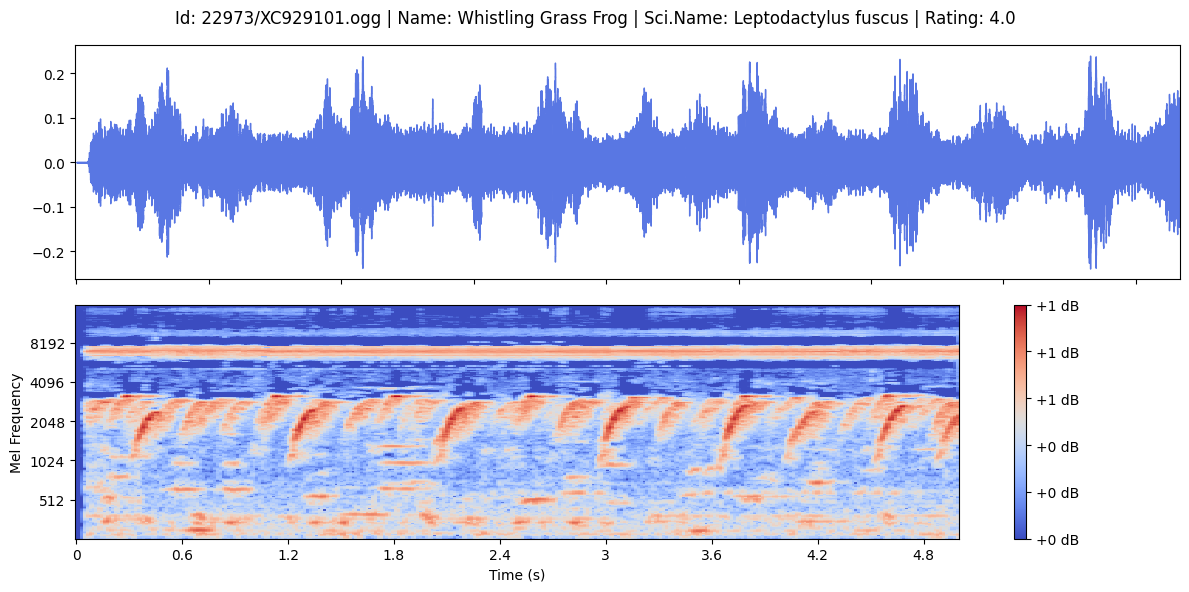

In [13]:
row = metadata.iloc[189]
print(f"\nProcessing: {row.filepath}")
display_audio(row)

### Kiểm tra xem có nhãn NaN không

In [14]:
empty_labels = metadata[metadata['primary_label'].isna() | (metadata['primary_label'].str.strip() == '')]
len(empty_labels)

0

### Rating 5.0

In [16]:
first_index_5_rating = metadata[metadata['rating'] == 5.0].index[0]
print(f"Chỉ số (index) đầu tiên có rating = 5.0 là: {first_index_5_rating}")

Chỉ số (index) đầu tiên có rating = 5.0 là: 121



Processing: /kaggle/input/birdclef-2025/train_audio/21211/XC934741.ogg
# Audio:


# Visualization:


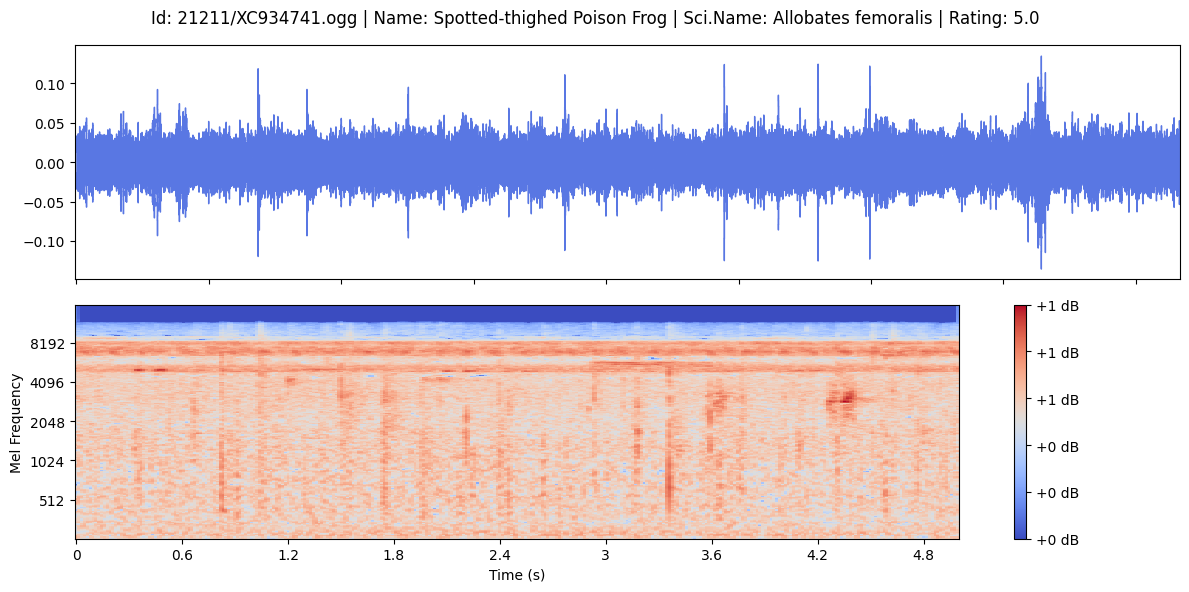

In [17]:
row = metadata.iloc[121]
print(f"\nProcessing: {row.filepath}")
display_audio(row)

### Rating 0.0

In [18]:
first_index_0_rating = metadata[metadata['rating'] == 0.0].index[0]
print(f"Chỉ số (index) đầu tiên có rating = 0.0 là: {first_index_0_rating}")

Chỉ số (index) đầu tiên có rating = 0.0 là: 0



Processing: /kaggle/input/birdclef-2025/train_audio/1139490/CSA36385.ogg
# Audio:


# Visualization:


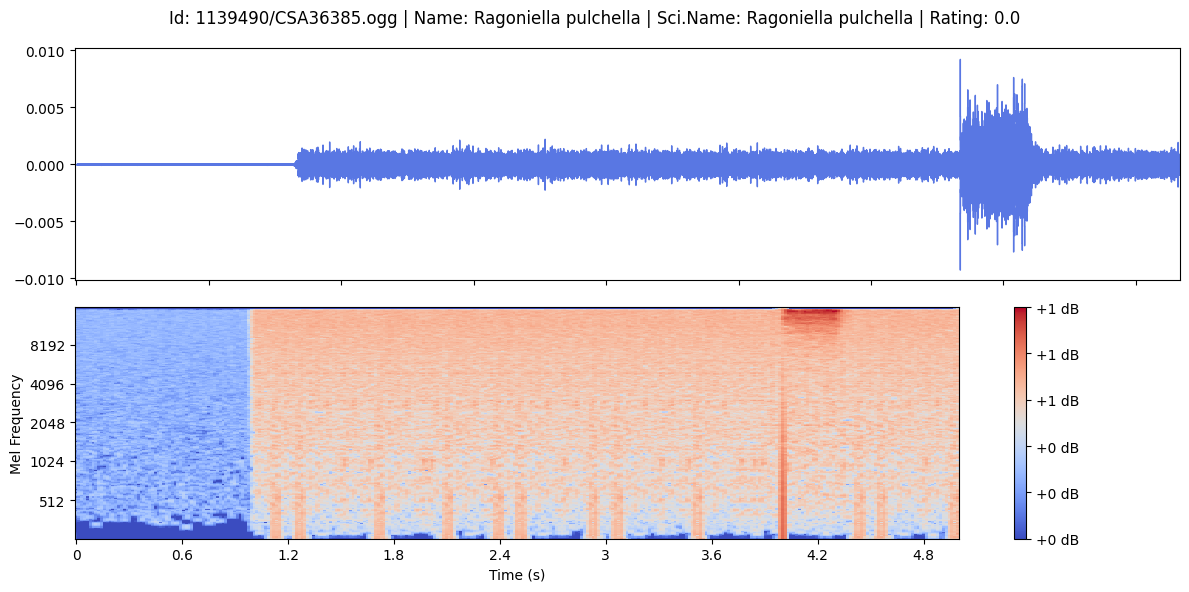

In [19]:
row = metadata.iloc[0]
print(f"\nProcessing: {row.filepath}")
display_audio(row)

### Kiểm tra tổng số nhãn

In [10]:
all_labels = sorted(metadata['primary_label'].unique())
print(f"Total labels: {len(all_labels)}")

Total labels: 206


### Kiểm tra phân bố samples của các labels

In [11]:
label_counts = metadata['primary_label'].value_counts()
print("Phân bố số mẫu mỗi loài:")

for label, count in label_counts.items():
    print(f"{label}: {count} mẫu")

min_samples = label_counts.min()
max_samples = label_counts.max()
rare_species = [label for label, count in label_counts.items() if count < min_samples * 2]
common_species = [label for label, count in label_counts.items() if count > max_samples * 0.5]

print(f"Số loài hiếm (<{min_samples * 2} mẫu): {len(rare_species)}")
print(f"Số loài phổ biến (>{max_samples * 0.5} mẫu): {len(common_species)}")

Phân bố số mẫu mỗi loài:
grekis: 990 mẫu
compau: 808 mẫu
trokin: 787 mẫu
roahaw: 709 mẫu
banana: 610 mẫu
whtdov: 572 mẫu
socfly1: 543 mẫu
yeofly1: 525 mẫu
bobfly1: 514 mẫu
wbwwre1: 499 mẫu
soulap1: 487 mẫu
sobtyr1: 478 mẫu
trsowl: 470 mẫu
laufal1: 467 mẫu
strcuc1: 431 mẫu
bbwduc: 424 mẫu
saffin: 419 mẫu
amekes: 409 mẫu
tropar: 397 mẫu
compot1: 383 mẫu
blbgra1: 380 mẫu
bubwre1: 379 mẫu
strfly1: 377 mẫu
gycwor1: 365 mẫu
greegr: 340 mẫu
linwoo1: 330 mẫu
pirfly1: 324 mẫu
littin1: 323 mẫu
bkmtou1: 311 mẫu
yercac1: 302 mẫu
butsal1: 298 mẫu
smbani: 287 mẫu
bugtan: 280 mẫu
chbant1: 270 mẫu
yebela1: 267 mẫu
rutjac1: 261 mẫu
cotfly1: 260 mẫu
whbman1: 246 mẫu
yehcar1: 238 mẫu
solsan: 237 mẫu
rumfly1: 236 mẫu
yecspi2: 235 mẫu
blhpar1: 230 mẫu
creoro1: 229 mẫu
paltan1: 224 mẫu
rinkin1: 222 mẫu
orcpar: 218 mẫu
stbwoo2: 210 mẫu
speowl1: 201 mẫu
yebfly1: 188 mẫu
plbwoo1: 186 mẫu
yebsee1: 185 mẫu
bkcdon: 176 mẫu
y00678: 169 mẫu
strher: 169 mẫu
babwar: 167 mẫu
strowl1: 164 mẫu
gybmar: 164 mẫu
cocwoo1: 1

### Có bao nhiêu nhãn cực ít?

In [12]:
min_samples_threshold = 10
rare_labels = [label for label, count in label_counts.items() if count < min_samples_threshold]
print(f"Số nhãn hiếm (< {min_samples_threshold} mẫu): {len(rare_labels)}")

Số nhãn hiếm (< 10 mẫu): 39


### Chia data sử dụng stratified (đảm bảo train/ val chứa đủ toàn bộ labels)

In [13]:
def split_train_val(metadata, test_size=0.2, random_state=42):
    train_data = pd.DataFrame()
    val_data = pd.DataFrame()

    for label in rare_labels:
        label_data = metadata[metadata['primary_label'] == label]
        
        # Chọn ngẫu nhiên 1 mẫu cho val, còn lại cho train
        val_sample = label_data.sample(n=1, random_state=random_state)
        train_samples = label_data.drop(val_sample.index)
        train_data = pd.concat([train_data, train_samples])
        val_data = pd.concat([val_data, val_sample])

    # Lọc dữ liệu còn lại 
    remaining_data = metadata[~metadata['primary_label'].isin(rare_labels)]
    
    if not remaining_data.empty:
        # Chia stratified cho các nhãn còn lại
        splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        
        for train_idx, val_idx in splitter.split(remaining_data, remaining_data['primary_label']):
            train_data = pd.concat([train_data, remaining_data.iloc[train_idx]])
            val_data = pd.concat([val_data, remaining_data.iloc[val_idx]])

    return train_data, val_data

### Data Splitting

In [14]:
train_data, val_data = split_train_val(metadata, test_size=0.2, random_state=42)

# Kiểm tra phân bố
print(f"Tổng số mẫu train: {len(train_data)} ({len(train_data)/len(metadata)*100:.1f}%)")
print(f"Tổng số mẫu val: {len(val_data)} ({len(val_data)/len(metadata)*100:.1f}%)")
print(f"Số nhãn trong train: {len(train_data['primary_label'].unique())}")
print(f"Số nhãn trong val: {len(val_data['primary_label'].unique())}")

Tổng số mẫu train: 22842 (80.0%)
Tổng số mẫu val: 5722 (20.0%)
Số nhãn trong train: 206
Số nhãn trong val: 206


In [15]:
val_data = val_data.sort_index()
train_data = train_data.sort_index()

In [16]:
print(train_data.iloc[1827])

primary_label                                                  banana
secondary_labels                                                 ['']
type                                                             ['']
filename                                        banana/iNat597011.ogg
collection                                                       iNat
rating                                                            0.0
url                  https://static.inaturalist.org/sounds/597011.wav
latitude                                                      18.4731
longitude                                                    -69.8893
scientific_name                                      Coereba flaveola
common_name                                                Bananaquit
author                                                        Unknown
license                                                  cc-by-nc 4.0
filepath            /kaggle/input/birdclef-2025/train_audio/banana...
Name: 2287, dtype: o

### Đừng dẫn tới file audio thô đã được tiền xử lý trước và chuyển thành mel 

In [17]:
mel_train_pretrain = '/kaggle/input/dataset/mel_train/mel_train/'
mel_val_pretrain = '/kaggle/input/dataset/mel_val/mel_val'

In [18]:
mel_val_path = mel_val_pretrain
mel_train_path = mel_train_pretrain

print(f"Number of val Mel-spectrograms: {len(os.listdir(mel_val_path))}")
print(f"Number of train Mel-spectrograms: {len(os.listdir(mel_train_path))}")

Number of val Mel-spectrograms: 5722
Number of train Mel-spectrograms: 22842


---

### MelSpectrogram

In [19]:
class MelSpectrogram:
    def __init__(self, cfg):
        self.cfg = cfg
        self.mel_params = {
            'sr': cfg.sample_rate,
            'n_mels': cfg.n_mels,
            'fmin': cfg.fmin,
            'fmax': cfg.fmax,
            'n_fft': cfg.n_fft,
            'hop_length': cfg.hop_length,
            'power': cfg.power,
            'norm': cfg.norm,
            'pad_mode': cfg.pad_mode,
            'center': True
        }

    def audio_to_mel(self, audio):
        # Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=audio, **self.mel_params)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max, top_db=self.cfg.top_db)
        mel_spec_norm = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-8) # 1e-8 giúp đảm bảo không về 0

        # RGB: [H, W, 3]
        mel_spec_rgb = np.stack([mel_spec_norm] * 3, axis=-1)
        
        # Chuyển sang tensor [3, H, W] 
        mel_spec_rgb = torch.from_numpy(mel_spec_rgb).float().permute(2, 0, 1) 
        
        # Resize
        mel_spec_rgb = transforms_v2.functional.resize(
            mel_spec_rgb, 
            self.cfg.target_shape,
            interpolation=transforms_v2.InterpolationMode.BILINEAR
        ).numpy()  # [3, H, W]

        return mel_spec_rgb

### Đổi dữ liệu sang mel trước (chuẩn bị cho data cho quá trình huấn luyện) và lưu vào file npy

In [20]:
def preprocess_and_save_mel_spectrograms(dataset, cfg, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    mel_converter = MelSpectrogram(cfg)

    for idx in range(len(dataset)):
        row = dataset.metadata.iloc[idx]
        audio = dataset.load_audio(row['filepath'])
        mel_spec = mel_converter.audio_to_mel(audio)
        
        np.save(os.path.join(output_dir, f'mel_{idx}.npy'), mel_spec)
        
        if idx % 100 == 0:
            print(f"Processed {idx}/{len(dataset)} samples")

In [21]:
class BirdCLEFDataset:
    def __init__(self, metadata, cfg, mode='train', all_labels=None, mel_dir=None):
        self.metadata = metadata
        self.cfg = cfg
        self.mode = mode
        self.mel_dir = mel_dir
        
        if mel_dir is None:
            self.mel_converter = MelSpectrogram(cfg) # Nếu tiền xử lý lỗi thì cần tạo lại
            
        self.labels = all_labels
        self.label2idx = {label: idx for idx, label in enumerate(self.labels)}

    def __len__(self):
        return len(self.metadata)

    def load_audio(self, filepath):
        audio, sr = librosa.load(filepath, sr=self.cfg.sample_rate)
        target_length = int(self.cfg.sample_rate * self.cfg.segment_length)
        
        if sr != self.cfg.sample_rate:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=self.cfg.sample_rate)
            
        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
        else:
            audio = audio[:target_length]
            
        return audio

    def get_item(self, idx):
        row = self.metadata.iloc[idx]
        
        if self.mel_dir and os.path.exists(os.path.join(self.mel_dir, f'mel_{idx}.npy')):
            mel_spec = np.load(os.path.join(self.mel_dir, f'mel_{idx}.npy'))
        else:
            audio = self.load_audio(row['filepath'])
            mel_spec = self.mel_converter.audio_to_mel(audio)
            
        label = np.zeros(len(self.labels), dtype=np.float32) # One-hot
        primary_label = row['primary_label']
        
        if primary_label != 'unlabel':  # Unlabel được sử dụng để gán nhãn tạm thời khi muốn sử dụng data không nhãn
            label[self.label2idx[primary_label]] = 1.0
            
        # Đối với tập không nhãn, trả về vector zero (không cần gán)
        return mel_spec, label

In [ ]:
train_dataset = BirdCLEFDataset(train_data, cfg, mode='train', all_labels=all_labels, mel_dir=mel_train_pretrain)
val_dataset = BirdCLEFDataset(val_data, cfg, mode='val', all_labels=all_labels, mel_dir=mel_val_pretrain)

---

# Dataset huấn luyện

In [22]:
class MelSpectrogramDataset(Dataset):
    def __init__(self, dataset, cfg, transform=None):
        self.dataset = dataset
        self.mel_dir = dataset.mel_dir
        self.cfg = cfg
        self.transform = transform
        
        if self.mel_dir is None: 
            self.mel_converter = MelSpectrogram(cfg)
            
        self.file_paths = [
            os.path.join(self.mel_dir, f'mel_{idx}.npy') if self.mel_dir else None
            for idx in range(len(dataset))
        ]
        self.labels = [dataset.get_item(idx)[1] for idx in range(len(dataset))]

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        
        if self.file_paths[idx] and os.path.exists(self.file_paths[idx]):
            mel_spec = np.load(self.file_paths[idx])
        else:
            row = self.dataset.metadata.iloc[idx]
            audio = self.dataset.load_audio(row['filepath'])
            mel_spec = self.mel_converter.audio_to_mel(audio)

        # Đổi sang tensor
        mel_spec = torch.from_numpy(mel_spec).float()
            
        # Kiểm tra xem có nhầm shape không
        if len(mel_spec.shape) == 3 and mel_spec.shape[-1] == self.cfg.in_channels:
             mel_spec = mel_spec.permute(2, 0, 1)  # [H, W, C] -> [C, H, W]
        elif mel_spec.shape[0] != self.cfg.in_channels:
             raise ValueError(f"Lỗi mel_spec shape: {mel_spec.shape}, Mong đợi [H, W, {self.cfg.in_channels}] hoặc [{self.cfg.in_channels}, H, W]")

        if self.transform:
            mel_spec = self.transform(mel_spec)

        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        
        return mel_spec, label

# Augmenter

In [23]:
def apply_mixup(images, labels, alpha=0.4, p=0.4):
    if torch.rand(1).item() > p:
        return images, labels
        
    beta_dist = torch.distributions.Beta(alpha, alpha) # phân phối Beta
    lam = beta_dist.sample().to(images.device)
    
    batch_size = images.size(0)
    
    index = torch.randperm(batch_size).to(images.device)
    
    mixed_images = lam * images + (1 - lam) * images[index]
    mixed_labels = lam * labels + (1 - lam) * labels[index]
    return mixed_images, mixed_labels

def build_augmenter(cfg):
    augmentations = [
        transforms_v2.RandomHorizontalFlip(p=0.5), # lật ảnh theo trục thời gian

        # Che 1 phân ảnh
        transforms_v2.RandomErasing( # Ngang
            p=0.35,
            scale=(0.06, 0.12),
            ratio=(0.3, 3.3),
            value=0.0
        ), 
        transforms_v2.RandomErasing( # Dọc
            p=0.35,
            scale=(0.06, 0.1),
            ratio=(3.0, 10.0),
            value=0.0
        )
    ]
    
    return transforms_v2.Compose(augmentations)

In [24]:
def create_dataloader(dataset, cfg, shuffle=False, augment=False):
    print(dataset.mel_dir)
    transform = build_augmenter(cfg) if augment else None
    torch_dataset = MelSpectrogramDataset(dataset, cfg, transform=transform)
    
    dataloader = DataLoader(
        torch_dataset,
        batch_size=cfg.batch_size,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=True,
        drop_last=True
    )
    
    return dataloader

In [37]:
train_dataloader = create_dataloader(train_dataset, cfg, shuffle=True, augment=True)
val_dataloader = create_dataloader(val_dataset, cfg, shuffle=False, augment=False)

/kaggle/input/dataset/mel_train/mel_train/
/kaggle/input/dataset/mel_val/mel_val


### Kiểm tra inputs

In [ ]:
for inputs, _ in train_dataloader:
    print(f"Input batch shape: {inputs.shape}")  # Mong đợi [32, 3, 256, 256]
    break

---

### Xây dựng model

In [27]:
def create_model(cfg, num_classes):
    # Tạo backbone
    backbone = timm.create_model(
        cfg.model_name,
        pretrained=True,  # Sử dụng pre-train weight
        in_chans=cfg.in_channels,
        num_classes=0,    # Bỏ fully connected layer
        drop_rate=0.0,
        drop_path_rate=0.0,
    )

    class BirdCLEFModel(nn.Module):
        def __init__(self, backbone, num_classes):
            super().__init__()
            self.backbone = backbone
            
            # Lấy số chiều đặc trưng bằng dummy input
            dummy_input = torch.randn(1, cfg.in_channels, cfg.target_shape[0], cfg.target_shape[1])
            with torch.no_grad():
                features = self.backbone(dummy_input)
                feat_dim = features.shape[-1] if len(features.shape) == 2 else features.shape[1]
            
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.classifier = nn.Linear(feat_dim, num_classes)

        def forward(self, x):
            features = self.backbone(x)
            
            if len(features.shape) == 4:
                features = self.pool(features).flatten(1)
            else:
                features = features.flatten(1)
                
            logits = self.classifier(features)
            return logits
    
    model = BirdCLEFModel(backbone, num_classes)
    
    return model

---

### BCEWithLogitsLoss

In [28]:
class FocalLossBCE(torch.nn.Module):
    def __init__(self,
            alpha: float = 0.3,
            gamma: float = 3.0,
            reduction: str = "mean",
            bce_weight: float = 0.6,
            focal_weight: float = 1.4):
        
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.bce = torch.nn.BCEWithLogitsLoss(reduction=reduction)
        self.bce_weight = bce_weight
        self.focal_weight = focal_weight

    def forward(self, logits, targets):
        focall_loss = torchvision.ops.focal_loss.sigmoid_focal_loss(
            inputs=logits,
            targets=targets,
            alpha=self.alpha,
            gamma=self.gamma,
            reduction=self.reduction,
        )
        
        bce_loss = self.bce(logits, targets)
        
        return self.bce_weight * bce_loss + self.focal_weight * focall_loss

In [29]:
def get_criterion(cfg):
    return FocalLossBCE()

---

### Trọng số đánh giá 

In [ ]:
def compute_f1_macro(all_logits, all_targets):
    logits = torch.softmax(torch.cat(all_logits), dim=1).cpu().detach().numpy()  # [N, 206]
    targets = torch.cat(all_targets).cpu().detach().numpy()  # [N, 206], one-hot
    target_indices = np.argmax(targets, axis=1) 
    predictions = np.argmax(logits, axis=1)  
    f1 = f1_score(target_indices, predictions, average='macro')
    
    return f1

### Huấn luyện model

In [30]:
def train_model(model, train_dataloader, val_dataloader, cfg, preset, train_dataset_len):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = model.to(device)
    criterion = get_criterion(cfg).to(device)
 
    steps_per_epoch = train_dataset_len // cfg.batch_size
    
    if train_dataset_len % cfg.batch_size != 0:
        steps_per_epoch += 1
        
    best_val_f1 = 0
    patience_counter = 0

    # Giai đoạn 1: Warm-up
    for name, param in model.named_parameters():
        param.requires_grad = 'classifier' in name
        
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.learning_rate)
    
    for epoch in range(2):
        model.train()
        running_loss = 0.0
        for _, (inputs, labels) in enumerate(train_dataloader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs) # Xoá gradient cũ 
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step() # Tính gradient loss 
            running_loss += loss.item() # Cộng dồn loss
        
        # Tính train_f1
        model.eval()
        all_logits = []
        all_targets = []
        with torch.no_grad():
            for inputs, labels in train_dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                all_logits.append(outputs)
                all_targets.append(labels)
        train_f1 = compute_f1_macro(all_logits, all_targets)
        
        # Tính val_f1 và val_loss
        val_f1 = 0.0
        val_loss = 0.0
        if len(val_dataloader) > 0:
            all_logits = []
            all_targets = []
            with torch.no_grad():
                for inputs, labels in val_dataloader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    val_loss += criterion(outputs, labels).item()
                    all_logits.append(outputs)
                    all_targets.append(labels)
                val_loss /= len(val_dataloader)
                val_f1 = compute_f1_macro(all_logits, all_targets)
        
        print(f"Epoch {epoch+1}/2 (Warm-up) - Loss: {running_loss / steps_per_epoch:.4f}, Val Loss: {val_loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}")

    # Giai đoạn 2: Mở 60% layer
    total_layers = sum(1 for _ in model.backbone.modules())
    trainable_layers = int(0.6 * total_layers)
    layer_count = 0
    
    for module in model.backbone.modules():
        if layer_count >= trainable_layers:
            for param in module.parameters():
                param.requires_grad = True
        layer_count += 1
        
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.learning_rate)
    
    for epoch in range(2):
        model.train()
        running_loss = 0.0
        for _, (inputs, labels) in enumerate(train_dataloader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        # Tính train_f1
        model.eval()
        all_logits = []
        all_targets = []
        with torch.no_grad():
            for inputs, labels in train_dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                all_logits.append(outputs)
                all_targets.append(labels)
        train_f1 = compute_f1_macro(all_logits, all_targets)
        
        # Tính val_f1 và val_loss
        val_f1 = 0.0
        val_loss = 0.0
        if len(val_dataloader) > 0:
            all_logits = []
            all_targets = []
            with torch.no_grad():
                for inputs, labels in val_dataloader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    val_loss += criterion(outputs, labels).item()
                    all_logits.append(outputs)
                    all_targets.append(labels)
                val_loss /= len(val_dataloader)
                val_f1 = compute_f1_macro(all_logits, all_targets)
        
        print(f"Epoch {epoch+1}/2 (Stage 2) - Loss: {running_loss / steps_per_epoch:.4f}, Val Loss: {val_loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}")

    # Giai đoạn 3: Mở toàn bộ với MixUp
    for param in model.parameters():
        param.requires_grad = True
    optimizer = optim.Adam(model.parameters(), lr=cfg.learning_rate * 0.3, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-5, verbose=True
    )
    
    for epoch in range(cfg.num_epochs - 4):
        model.train()
        running_loss = 0.0
        for _, (inputs, labels) in enumerate(train_dataloader):
            inputs, labels = inputs.to(device), labels.to(device)
            inputs, mixed_labels = apply_mixup(inputs, labels, alpha=cfg.mixup_alpha, p=0.4)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, mixed_labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        # Tính train_f1
        model.eval()
        all_logits = []
        all_targets = []
        with torch.no_grad():
            for inputs, labels in train_dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                all_logits.append(outputs)
                all_targets.append(labels)
        train_f1 = compute_f1_macro(all_logits, all_targets)
        
        # Tính val_f1 và val_loss
        val_f1 = 0.0
        val_loss = 0.0
        if len(val_dataloader) > 0:
            all_logits = []
            all_targets = []
            with torch.no_grad():
                for inputs, labels in val_dataloader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    val_loss += criterion(outputs, labels).item()
                    all_logits.append(outputs)
                    all_targets.append(labels)
                val_loss /= len(val_dataloader)
                val_f1 = compute_f1_macro(all_logits, all_targets)
        
        print(f"Epoch {epoch+1}/{cfg.num_epochs} (Stage 3) - Loss: {running_loss / steps_per_epoch:.4f}, Val Loss: {val_loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}")
        scheduler.step(val_f1)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), os.path.join(cfg.model_dir, f'{preset}_best.pth'))
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= cfg.early_stopping_patience:
            print("Early stopping triggered")
            break

    return model

In [48]:
# Huấn luyện
models = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for model_name in cfg.model_presets:  
    cfg.model_name = model_name
    model = create_model(cfg, len(train_dataset.labels))
    model = train_model(model, train_dataloader, val_dataloader, cfg, model_name, len(train_dataset))
    models.append(model)

Backbone: efficientnet_b0, Output dimension: 1280
Frozen 4/7 top-level modules: ['conv_stem', 'bn1', 'blocks', 'bn2']
Epoch 1/2 (Warm-up) - Loss: 0.0329, Val Loss: 0.0276, Train F1: 0.0612, Val F1: 0.0518
Epoch 2/2 (Warm-up) - Loss: 0.0234, Val Loss: 0.0248, Train F1: 0.1215, Val F1: 0.0865
Epoch 1/2 (Stage 2) - Loss: 0.0150, Val Loss: 0.0117, Train F1: 0.3811, Val F1: 0.3333
Epoch 2/2 (Stage 2) - Loss: 0.0107, Val Loss: 0.0106, Train F1: 0.5422, Val F1: 0.4296


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/20 (Stage 3) - Loss: 0.0089, Val Loss: 0.0092, Train F1: 0.5846, Val F1: 0.4547
Epoch 2/20 (Stage 3) - Loss: 0.0083, Val Loss: 0.0087, Train F1: 0.5871, Val F1: 0.4713
Epoch 3/20 (Stage 3) - Loss: 0.0083, Val Loss: 0.0086, Train F1: 0.5870, Val F1: 0.4857
Epoch 4/20 (Stage 3) - Loss: 0.0081, Val Loss: 0.0087, Train F1: 0.5879, Val F1: 0.4755
Epoch 5/20 (Stage 3) - Loss: 0.0081, Val Loss: 0.0086, Train F1: 0.5811, Val F1: 0.4781
Epoch 6/20 (Stage 3) - Loss: 0.0081, Val Loss: 0.0085, Train F1: 0.5785, Val F1: 0.4617
Epoch 7/20 (Stage 3) - Loss: 0.0070, Val Loss: 0.0075, Train F1: 0.6508, Val F1: 0.5214
Epoch 8/20 (Stage 3) - Loss: 0.0068, Val Loss: 0.0078, Train F1: 0.6573, Val F1: 0.5243
Epoch 9/20 (Stage 3) - Loss: 0.0067, Val Loss: 0.0078, Train F1: 0.6730, Val F1: 0.5178
Epoch 10/20 (Stage 3) - Loss: 0.0065, Val Loss: 0.0078, Train F1: 0.6624, Val F1: 0.5218
Epoch 11/20 (Stage 3) - Loss: 0.0064, Val Loss: 0.0079, Train F1: 0.6719, Val F1: 0.5257
Epoch 12/20 (Stage 3) - Loss: 

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/20 (Stage 3) - Loss: 0.0103, Val Loss: 0.0123, Train F1: 0.3549, Val F1: 0.3274
Epoch 2/20 (Stage 3) - Loss: 0.0105, Val Loss: 0.0101, Train F1: 0.4098, Val F1: 0.3573
Epoch 3/20 (Stage 3) - Loss: 0.0104, Val Loss: 0.0104, Train F1: 0.4055, Val F1: 0.3573
Epoch 4/20 (Stage 3) - Loss: 0.0103, Val Loss: 0.0102, Train F1: 0.4158, Val F1: 0.3616
Epoch 5/20 (Stage 3) - Loss: 0.0101, Val Loss: 0.0107, Train F1: 0.3985, Val F1: 0.3496
Epoch 6/20 (Stage 3) - Loss: 0.0101, Val Loss: 0.0098, Train F1: 0.4453, Val F1: 0.4013
Epoch 7/20 (Stage 3) - Loss: 0.0100, Val Loss: 0.0105, Train F1: 0.4331, Val F1: 0.3856
Epoch 8/20 (Stage 3) - Loss: 0.0097, Val Loss: 0.0132, Train F1: 0.3667, Val F1: 0.3341
Epoch 9/20 (Stage 3) - Loss: 0.0096, Val Loss: 0.0115, Train F1: 0.3686, Val F1: 0.3426
Epoch 10/20 (Stage 3) - Loss: 0.0082, Val Loss: 0.0083, Train F1: 0.5244, Val F1: 0.4581
Epoch 11/20 (Stage 3) - Loss: 0.0078, Val Loss: 0.0083, Train F1: 0.5542, Val F1: 0.4716
Epoch 12/20 (Stage 3) - Loss: 

---

# Sử dụng Data không nhãn Train_soundscapes

In [32]:
# Thư mục chứa audio không nhãn
train_soundscapes_dir = '/kaggle/input/birdclef-2025/train_soundscapes/'
audio_files = [f for f in os.listdir(train_soundscapes_dir) if f.endswith('.ogg')]

# Tạo DataFrame
pseudo_metadata = pd.DataFrame({
    'primary_label': 'unlabel',  # gán mặc định
    'filename': audio_files
})

# Tạo cột filepath
pseudo_metadata['filepath'] = pseudo_metadata['filename'].apply(lambda x: os.path.join(train_soundscapes_dir, x))

print(f"✅ Đã tạo Data không nhãn: {pseudo_metadata} với {len(pseudo_metadata)} samples")

✅ Đã tạo Data không nhãn:      primary_label                 filename  \
0          unlabel  H27_20230421_155000.ogg   
1          unlabel  H09_20230424_014500.ogg   
2          unlabel  H78_20230512_071000.ogg   
3          unlabel  H14_20230430_050500.ogg   
4          unlabel  H92_20230508_022000.ogg   
...            ...                      ...   
9721       unlabel  H71_20230430_115000.ogg   
9722       unlabel  H73_20230508_040500.ogg   
9723       unlabel  H73_20230509_053000.ogg   
9724       unlabel  H18_20230515_062000.ogg   
9725       unlabel  H93_20230425_005000.ogg   

                                               filepath  
0     /kaggle/input/birdclef-2025/train_soundscapes/...  
1     /kaggle/input/birdclef-2025/train_soundscapes/...  
2     /kaggle/input/birdclef-2025/train_soundscapes/...  
3     /kaggle/input/birdclef-2025/train_soundscapes/...  
4     /kaggle/input/birdclef-2025/train_soundscapes/...  
...                                                 ...  
972

In [33]:
mel_unlabel = '/kaggle/input/unlabel/mel_train_unlabel/'

In [34]:
paths = mel_unlabel
if os.path.exists(paths):
        print(f"{paths} ✅ tồn tại.")
else:
        print(f"{paths} ❌ không tồn tại.")

/kaggle/input/unlabel/mel_train_unlabel/ ✅ tồn tại.


In [35]:
train_dataset = BirdCLEFDataset(train_data, cfg, mode='train', all_labels=all_labels, mel_dir=mel_train_pretrain)
val_dataset = BirdCLEFDataset(val_data, cfg, mode='val', all_labels=all_labels, mel_dir=mel_val_pretrain)
unlabel_dataset = BirdCLEFDataset(pseudo_metadata, cfg, mode='train', all_labels=all_labels, mel_dir=mel_unlabel)

In [36]:
train_dataloader = create_dataloader(train_dataset, cfg, shuffle=True, augment=True)
val_dataloader = create_dataloader(val_dataset, cfg, shuffle=False, augment=False)
unlabel_dataloader = create_dataloader(unlabel_dataset, cfg, shuffle=True, augment=True)

/kaggle/input/dataset/mel_train/mel_train/
/kaggle/input/dataset/mel_val/mel_val
/kaggle/input/unlabel/mel_train_unlabel/


In [37]:
def train_model(model, train_dataloader, val_dataloader, unlabel_dataloader, cfg, preset, train_dataset_len):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.BCEWithLogitsLoss(reduction='mean').to(device)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.learning_rate)
    
    steps_per_epoch = train_dataset_len // cfg.batch_size
    if train_dataset_len % cfg.batch_size != 0:
        steps_per_epoch += 1
        
    best_val_f1 = 0
    patience_counter = 0

    # Hàm chọn top-k pseudo-labels từ dữ liệu không nhãn
    def get_pseudo_labels(unlabel_dataloader, model, device, k=7, confidence_threshold=0.7):
        model.eval() # Chế độ đánh gía k tính gradient
        pseudo_inputs = []
        pseudo_labels = []
        
        with torch.no_grad():
            for inputs, _ in unlabel_dataloader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                probs = torch.sigmoid(outputs)  # [batch_size, num_classes]
                topk_probs, topk_indices = torch.topk(probs, k, dim=1)  # [batch_size, k]
                
                # Chỉ lấy mẫu có xác suất cao nhất vượt ngưỡng
                max_probs = topk_probs[:, 0]  # Xác suất cao nhất
                valid_mask = max_probs > confidence_threshold
                
                if valid_mask.sum() > 0:
                    valid_inputs = inputs[valid_mask].cpu()
                    valid_probs = probs[valid_mask].cpu()
    
                    pseudo_inputs.append(valid_inputs)
                    pseudo_labels.append(pseudo_label)
                    
        if pseudo_inputs:
            pseudo_inputs = torch.cat(pseudo_inputs, dim=0)
            pseudo_labels = torch.cat(pseudo_labels, dim=0)
            return pseudo_inputs, pseudo_labels
        return None, None

    # Giai đoạn 1: Warm-up
    for name, param in model.named_parameters():
        param.requires_grad = 'classifier' in name
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.learning_rate)
    for epoch in range(2):
        model.train()
        running_loss = 0.0
        for _, (inputs, labels) in enumerate(train_dataloader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        # Tính train_f1
        model.eval()
        all_logits = []
        all_targets = []
        with torch.no_grad():
            for inputs, labels in train_dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                all_logits.append(outputs)
                all_targets.append(labels)
        train_f1 = compute_f1_macro(all_logits, all_targets)
        
        # Tính val_f1 và val_loss
        val_f1 = 0.0
        val_loss = 0.0
        if len(val_dataloader) > 0:
            all_logits = []
            all_targets = []
            with torch.no_grad():
                for inputs, labels in val_dataloader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    val_loss += criterion(outputs, labels).item()
                    all_logits.append(outputs)
                    all_targets.append(labels)
                val_loss /= len(val_dataloader)
                val_f1 = compute_f1_macro(all_logits, all_targets)
        
        print(f"Epoch {epoch+1}/2 (Warm-up) - Loss: {running_loss / steps_per_epoch:.4f}, Val Loss: {val_loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}")

    # Giai đoạn 2: Mở 60% layer 
    total_layers = sum(1 for _ in model.backbone.modules())
    trainable_layers = int(0.6 * total_layers)
    layer_count = 0
    for module in model.backbone.modules():
        if layer_count >= trainable_layers:
            for param in module.parameters():
                param.requires_grad = True
        layer_count += 1
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.learning_rate)
    for epoch in range(2):
        model.train()
        running_loss = 0.0
        for _, (inputs, labels) in enumerate(train_dataloader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        # Tính train_f1
        model.eval()
        all_logits = []
        all_targets = []
        with torch.no_grad():
            for inputs, labels in train_dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                all_logits.append(outputs)
                all_targets.append(labels)
        train_f1 = compute_f1_macro(all_logits, all_targets)
        
        # Tính val_f1 và val_loss
        val_f1 = 0.0
        val_loss = 0.0
        if len(val_dataloader) > 0:
            all_logits = []
            all_targets = []
            with torch.no_grad():
                for inputs, labels in val_dataloader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    val_loss += criterion(outputs, labels).item()
                    all_logits.append(outputs)
                    all_targets.append(labels)
                val_loss /= len(val_dataloader)
                val_f1 = compute_f1_macro(all_logits, all_targets)
        
        print(f"Epoch {epoch+1}/2 (Stage 2) - Loss: {running_loss / steps_per_epoch:.4f}, Val Loss: {val_loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}")

    # Giai đoạn 3: 
    for param in model.parameters():
        param.requires_grad = True
    optimizer = optim.Adam(model.parameters(), lr=cfg.learning_rate * 0.3, weight_decay=8e-6)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-5, verbose=True
    )
    
    for epoch in range(cfg.num_epochs - 4):
        model.train()
        running_loss = 0.0
        labeled_loss_total = 0.0
        unlabeled_loss_total = 0.0
        num_batches = 0
        
        # Tạo pseudo-labels từ dữ liệu không nhãn
        pseudo_inputs, pseudo_labels = get_pseudo_labels(unlabel_dataloader, model, device, k=7, confidence_threshold=0.7)
        
        # Nếu có pseudo-labels, tạo dataloader tạm thời
        if pseudo_inputs is not None:
            pseudo_dataset = torch.utils.data.TensorDataset(pseudo_inputs, pseudo_labels)
            pseudo_dataloader = torch.utils.data.DataLoader(
                pseudo_dataset,
                batch_size=cfg.batch_size,
                shuffle=True,
                num_workers=2,
                pin_memory=True,
                drop_last=True
            )
        else:
            pseudo_dataloader = None
        
        # Huấn luyện với cả dữ liệu có nhãn và không nhãn
        for _, (inputs, labels) in enumerate(train_dataloader):
            inputs, labels = inputs.to(device), labels.to(device)
            inputs, mixed_labels = apply_mixup(inputs, labels, alpha=cfg.mixup_alpha, p=0.4)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            labeled_loss = criterion(outputs, mixed_labels)
            
            # Loss từ dữ liệu không nhãn
            unlabeled_loss = 0.0
            if pseudo_dataloader:
                try:
                    pseudo_inputs, pseudo_labels = next(iter(pseudo_dataloader))
                    pseudo_inputs, pseudo_labels = pseudo_inputs.to(device), pseudo_labels.to(device)
                    pseudo_outputs = model(pseudo_inputs)
                    unlabeled_loss = criterion(pseudo_outputs, pseudo_labels) * 0.8  # Trọng số 0.8
                except StopIteration:
                    pass
            
            # Tổng loss
            total_loss = labeled_loss + unlabeled_loss
            total_loss.backward()
            optimizer.step()
            
            running_loss += total_loss.item()
            labeled_loss_total += labeled_loss.item()
            if unlabeled_loss > 0:
                unlabeled_loss_total += unlabeled_loss.item()
            num_batches += 1
        
        # Tính trung bình loss
        avg_running_loss = running_loss / num_batches if num_batches > 0 else 0
        avg_labeled_loss = labeled_loss_total / num_batches if num_batches > 0 else 0
        avg_unlabeled_loss = unlabeled_loss_total / num_batches if num_batches > 0 else 0
        
        # Tính train_f1
        model.eval()
        
        all_logits = []
        all_targets = []
        
        with torch.no_grad():
            for inputs, labels in train_dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                all_logits.append(outputs)
                all_targets.append(labels)
        train_f1 = compute_f1_macro(all_logits, all_targets)
        
        # Tính val_f1 và val_loss
        val_f1 = 0.0
        val_loss = 0.0
        
        if len(val_dataloader) > 0:
            all_logits = []
            all_targets = []
            with torch.no_grad():
                for inputs, labels in val_dataloader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    val_loss += criterion(outputs, labels).item()
                    all_logits.append(outputs)
                    all_targets.append(labels)
                val_loss /= len(val_dataloader)
                val_f1 = compute_f1_macro(all_logits, all_targets)
        
        print(f"Epoch {epoch+1}/{cfg.num_epochs-4} (Stage 3) - Total Loss: {avg_running_loss:.4f}, Labeled Loss: {avg_labeled_loss:.4f}, Unlabeled Loss: {avg_unlabeled_loss:.4f}, Val Loss: {val_loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}")
        
        scheduler.step(val_f1)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), os.path.join(cfg.model_dir, f'{preset}.pth'))
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= cfg.early_stopping_patience:
            print("Early stopping triggered")
            break
    
    return model

In [38]:
# Huấn luyện
models = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for model_name in cfg.model_presets:  
    cfg.model_name = model_name
    model = create_model(cfg, len(train_dataset.labels))
    model = train_model(model, train_dataloader, val_dataloader, unlabel_dataloader, cfg, model_name, len(train_dataset))
    models.append(model)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Frozen 4/7 top-level modules: ['conv_stem', 'bn1', 'blocks', 'bn2']
Epoch 1/2 (Warm-up) - Loss: 0.0400, Val Loss: 0.0329, Train F1: 0.0503, Val F1: 0.0433
Epoch 2/2 (Warm-up) - Loss: 0.0274, Val Loss: 0.0292, Train F1: 0.0950, Val F1: 0.0727
Epoch 1/2 (Stage 2) - Loss: 0.0174, Val Loss: 0.0136, Train F1: 0.3922, Val F1: 0.3346
Epoch 2/2 (Stage 2) - Loss: 0.0124, Val Loss: 0.0120, Train F1: 0.5279, Val F1: 0.4230


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/16 (Stage 3) - Total Loss: 0.0224, Labeled Loss: 0.0120, Unlabeled Loss: 0.0104, Val Loss: 0.0112, Train F1: 0.5680, Val F1: 0.4582
Epoch 2/16 (Stage 3) - Total Loss: 0.0271, Labeled Loss: 0.0111, Unlabeled Loss: 0.0160, Val Loss: 0.0108, Train F1: 0.5600, Val F1: 0.4534
Epoch 3/16 (Stage 3) - Total Loss: 0.0222, Labeled Loss: 0.0106, Unlabeled Loss: 0.0115, Val Loss: 0.0104, Train F1: 0.5732, Val F1: 0.4731
Epoch 4/16 (Stage 3) - Total Loss: 0.0209, Labeled Loss: 0.0107, Unlabeled Loss: 0.0103, Val Loss: 0.0107, Train F1: 0.5773, Val F1: 0.4625
Epoch 5/16 (Stage 3) - Total Loss: 0.0194, Labeled Loss: 0.0101, Unlabeled Loss: 0.0093, Val Loss: 0.0103, Train F1: 0.6035, Val F1: 0.4901
Epoch 6/16 (Stage 3) - Total Loss: 0.0190, Labeled Loss: 0.0101, Unlabeled Loss: 0.0088, Val Loss: 0.0104, Train F1: 0.6178, Val F1: 0.4954
Epoch 7/16 (Stage 3) - Total Loss: 0.0181, Labeled Loss: 0.0099, Unlabeled Loss: 0.0083, Val Loss: 0.0105, Train F1: 0.6171, Val F1: 0.5036
Epoch 8/16 (Stage 3)